In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Sampler, BatchSampler, Dataset, DataLoader, Subset, SubsetRandomSampler, random_split
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from matplotlib import pyplot as plt
import lmfit
from scipy import interpolate
from scipy import stats
import h5py
import pandas as pd
#import tables

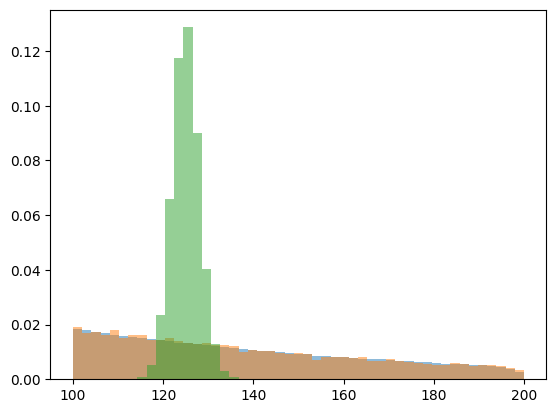

In [2]:
f_qcd0='data/bkg_bb_aa.h5'
f_qcd1='data/bkg_bb_aa_v2.h5'
f_hh1='data/sm_dihiggs.h5'
f_qcd_mc = h5py.File(f_qcd0,'r')
f_qcd_da = h5py.File(f_qcd1,'r')
f_hh  = h5py.File(f_hh1,'r')
#print(f_qcd['feats'].shape,f_qcd['photons'].shape,f_qcd['bjets'].shape,f_hh['feats'].shape)
#print(f_qcd['bjets'][0,:])

bins=np.linspace(100,200,50)
plt.hist(f_qcd_mc['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.hist(f_qcd_da['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.hist(f_hh['feats'][:,2],bins=bins,alpha=0.5,density=True)
plt.show()

def convert(iData):
    cols = [f"dog_{i}" for i in range(iData.shape[1])]
    dfs = pd.DataFrame(iData, columns=cols)
    cols = ["dog_0","dog_1","dog_3","dog_4","dog_5","dog_6","dog_7","dog_8","dog_9","dog_10","dog_2"]
    dfs=dfs.reindex(columns=cols)
    return dfs
hh_data  = convert(f_hh['feats'])
qcd_data = convert(f_qcd_da['feats'])
qcd_mc   = convert(f_qcd_mc['feats'])

def plotHist(iFeat):
    counts, bin_edges, patches = plt.hist(f_qcd_mc['feats'][:,i0],bins=30,alpha=0.5,density=True)
    plt.hist(f_qcd_da['feats'][:,i0],bins=bin_edges,alpha=0.5,density=True)
    plt.hist(f_hh['feats'][:,i0],bins=bin_edges,alpha=0.5,density=True)
    plt.show()

#for i0 in range(10):
#    plotHist(i0)

In [3]:
class DataSet(Dataset):
    def __init__(self, samples, labels, disc):
        super(DataSet, self).__init__()
        self.labels  = labels
        self.samples = samples
        self.disc    = disc
        if len(samples) != len(labels):
            raise ValueError(
                f"should have the same number of samples({len(samples)}) as there are labels({len(labels)})")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        y = self.labels[index]
        x = self.samples[index]
        z = self.disc[index]
        return x, y, z 
    
def mass(iDS): 
    e12   = np.sqrt(iDS.pxj1**2 + iDS.pyj1**2 + iDS.pzj1**2 + iDS.mj1**2)
    e22   = np.sqrt(iDS.pxj2**2 + iDS.pyj2**2 + iDS.pzj2**2 + iDS.mj2**2)
    etot  = e12 + e22
    pxtot = iDS.pxj1 + iDS.pxj2
    pytot = iDS.pyj1 + iDS.pyj2
    pztot = iDS.pzj1 + iDS.pzj2
    return np.sqrt(etot**2 - pxtot**2 - pytot**2 - pztot**2)

def makeNP(iDS):
    massvals=mass(iDS)
    tmp=iDS[["mj1","tau1j1","tau2j1","tau3j1","mj2","tau1j2","tau2j2","tau3j2"]].to_numpy()
    massvals=np.reshape(massvals,(len(massvals),1))
    tmp=np.hstack((tmp,massvals))
    print(len(tmp))
    return tmp

def makeDataSet(iD,iNS,iNB):
    pD    = torch.from_numpy(iD)
    discs = torch.cat((torch.ones(iNS), torch.zeros(iNB)))
    rand  = torch.randperm(len(pD))
    pXD   = pD[rand]
    tot   = pXD[:,:-1].float()   #this is our discriminator we want to learn
    label = pXD[:,-1].float()  ####Note this is a regression, so we want to put y=f(x)
    xdisc = discs[rand]
    datatrain=DataSet(samples=tot,labels=label, disc=xdisc)
    bkgdatatrain=DataSet(samples=pD[iNS:,:-1].float(),labels=pD[iNS:,-1].float(),disc=torch.zeros(iNB))
    return datatrain,bkgdatatrain,pD[0:iNS].float(),pD[iNS:].float()

def plotSigBkg(iN,sig,bkg,nbins=50):
    tot=torch.cat((sig,bkg))
    for pVar in range(iN+2):
        xmin=torch.min(bkg[:,pVar])
        xmax=torch.max(bkg[:,pVar])
        binrange=np.arange(xmin,xmax,(xmax-xmin)/nbins)
        plt.hist(sig[:,pVar],bins=binrange,density=True,alpha=0.5,label='sig')
        plt.hist(bkg[:,pVar],bins=binrange,density=True,alpha=0.5,label='bkg')
        plt.hist(tot[:,pVar],bins=binrange,density=True,alpha=0.5,label='tot')
        plt.legend()
        plt.show()

def setupData(iParr1,iParr2,iNB,iNS,iStart=0,iSStart=0):
    nparr1=iParr1[iStart:(iStart+iNB)]
    nparr2=iParr2[iSStart:(iSStart+iNS)]
    pdata = np.vstack((nparr2,nparr1))
    data,bkgdata,test_sig,test_bkg=makeDataSet(pdata,len(nparr2),len(nparr1))
    #plotSigBkg(9,test_sig,test_bkg)
    return data,bkgdata,test_sig,test_bkg

dataset,mcdataset,sig,bkg    =setupData(qcd_data,hh_data,7000,40) #3ab yield
dataset2,mcdataset2,sig2,bkg2=setupData(qcd_mc  ,hh_data,20000,20000,10000,1000)
dataset3,mcdataset3,sig3,bkg3=setupData(qcd_data,hh_data,20000,20000,8000,1000)
print(len(dataset),len(dataset2))

7040 40000


In [4]:
%load_ext autoreload
%autoreload 2
from splitfitter import simple_MLPFit_lmfit,fitGausLin,fitGausPowLaw,fitGausFlat,fitGausDijet,fitGausBern,plotPerf,plotCheck

In [244]:
model_basic = simple_MLPFit_lmfit(dataset,10,k_fold=1,nhidden=32,out_channels=1,act_out=False,n_epochs=10,fit_opt=2,bkg_loss=10.0,iFitPFunc=fitGausBern(),iFitFFunc=fitGausBern(),
                                massDeco=0.,mc_data=mcdataset,bkgPressure=True,lambScale=0.0,batch_size=7040,lambvar=0.)
model_basic.pretrain(dataset3,5000,21)
#model_basic.train(51)


Epoch: 0 LOSS train: 6.740102767944336 
Epoch: 10 LOSS train: 3.2850561141967773 
Epoch: 20 LOSS train: 2.9455273151397705 
Checkpoint saved to checkpoint.pth


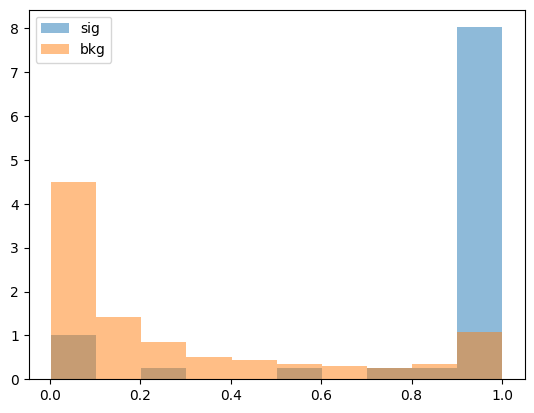

[[Model]]
    Model(funcSig_np)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 40
    # variables        = 4
    chi-square         = 16.5182771
    reduced chi-square = 0.45884103
    Akaike info crit   = -27.3764794
    Bayesian info crit = -20.6209615
    R-squared          = 0.97437703
[[Variables]]
    par0:  28.1556458 +/- 12.6878103 (45.06%) (init = 50)
    par1:  8.32860612 +/- 1.75894298 (21.12%) (init = 50)
    par2:  125 (fixed)
    par3:  2.5 (fixed)
    par4: -0.10561246 +/- 0.20398023 (193.14%) (init = 0)
    par5: -2.2872e-04 +/- 8.0121e-04 (350.31%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(par4, par5) = -0.998
    C(par0, par4) = -0.997
    C(par0, par5) = 0.990
    C(par1, par5) = 0.294
    C(par1, par4) = -0.289
    C(par0, par1) = 0.276


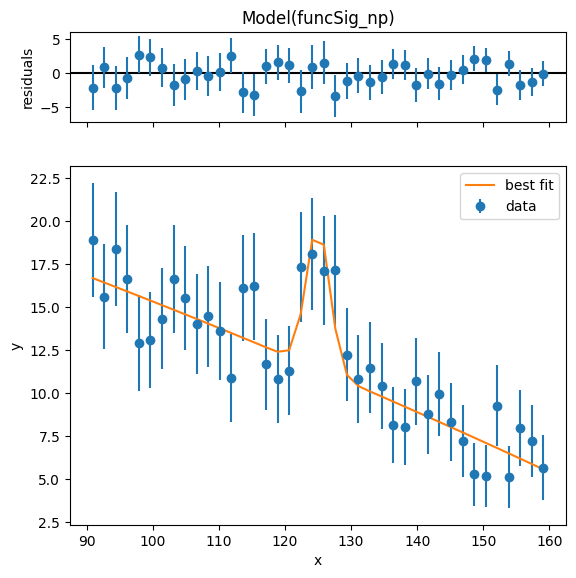

Pass Significance: 10.287348577700314
[[Model]]
    Model(funcSig_np)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 40
    # variables        = 4
    chi-square         = 31.4018864
    reduced chi-square = 0.87227462
    Akaike info crit   = -1.68045949
    Bayesian info crit = 5.07505833
    R-squared          = 0.99111646
[[Variables]]
    par0:  134.231087 +/- 27.5117085 (20.50%) (init = 50)
    par1:  0.15049730 +/- 3.10868124 (2065.61%) (init = 50)
    par2:  125 (fixed)
    par3:  2.5 (fixed)
    par4: -1.27749448 +/- 0.44142262 (34.55%) (init = 0)
    par5:  0.00338614 +/- 0.00173285 (51.17%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(par4, par5) = -0.998
    C(par0, par4) = -0.997
    C(par0, par5) = 0.990
    C(par1, par5) = 0.339
    C(par1, par4) = -0.332
    C(par0, par1) = 0.317
Fail Significance: 0.0020240323214650857


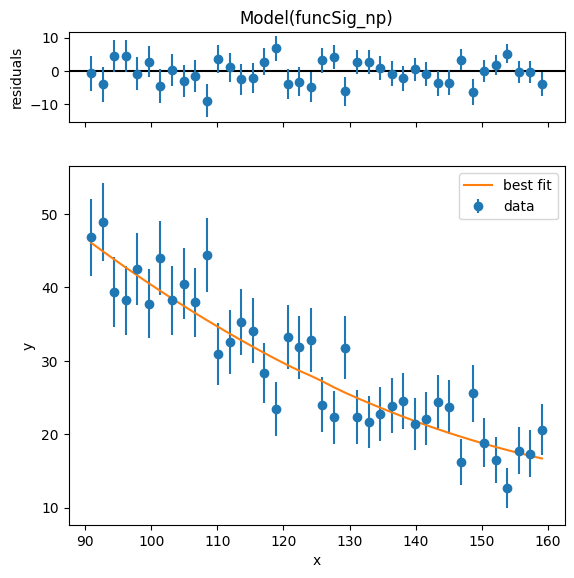

here!
torch.Size([7000, 1]) torch.Size([7000])
tensor([101.1338,  69.2160,  81.7647,  ...,  85.8496,  49.1674,  51.4697])
Bkg Significance: 0.9134662324223797


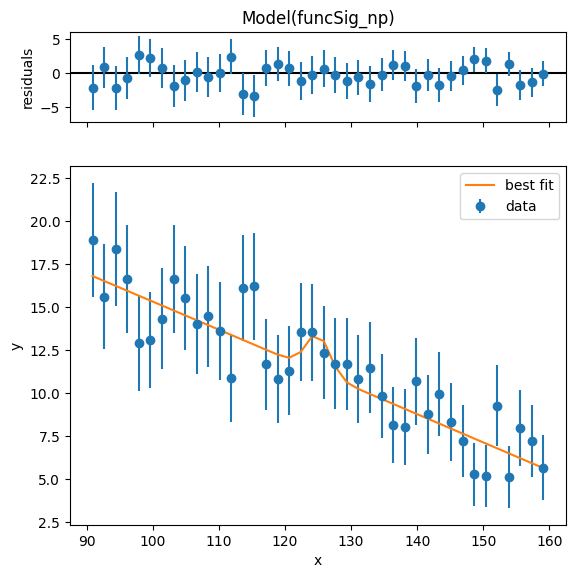

In [252]:
#model_basic.otlossdiff = 100
model_basic.reloadData(dataset)
model_basic.train(20,iLoad=True)
plotPerf(sig,bkg,model_basic)

In [ ]:
from splitfitter import trainToys

trainToys(sig2,bkg2,model_basic,40,7000,50,"bkg2")

toy: 0
toy: 1
toy: 2
toy: 3
toy: 4
toy: 5
toy: 6
toy: 7
toy: 8
toy: 9
toy: 10
toy: 11
toy: 12
toy: 13
toy: 14
toy: 15
toy: 16
toy: 17
toy: 18
toy: 19
toy: 20
toy: 21
toy: 22
toy: 23
toy: 24
toy: 25
toy: 26
toy: 27
toy: 28
toy: 29
toy: 30
toy: 31


toy: 0
toy: 100
toy: 200
toy: 300
toy: 400
toy: 500
toy: 600
toy: 700
toy: 800
toy: 900
toy: 1000
toy: 1100
toy: 1200
toy: 1300
toy: 1400
toy: 1500
toy: 1600
toy: 1700
toy: 1800
toy: 1900
Z-score: -2.807033768343811 p-value: 0.9975


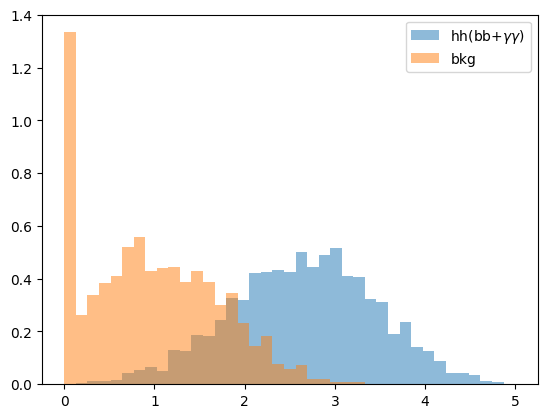

In [168]:
from splitfitter import plotPerfToys

#plotPerf(sig,bkg,model_basic)
plotPerfToys(sig2,bkg2,model_basic,-1,40,7000,2000)

tensor(1., grad_fn=<MaxBackward1>) tensor(3.8315e-17, grad_fn=<MinBackward1>)
torch.Size([7040]) torch.Size([7040, 1])


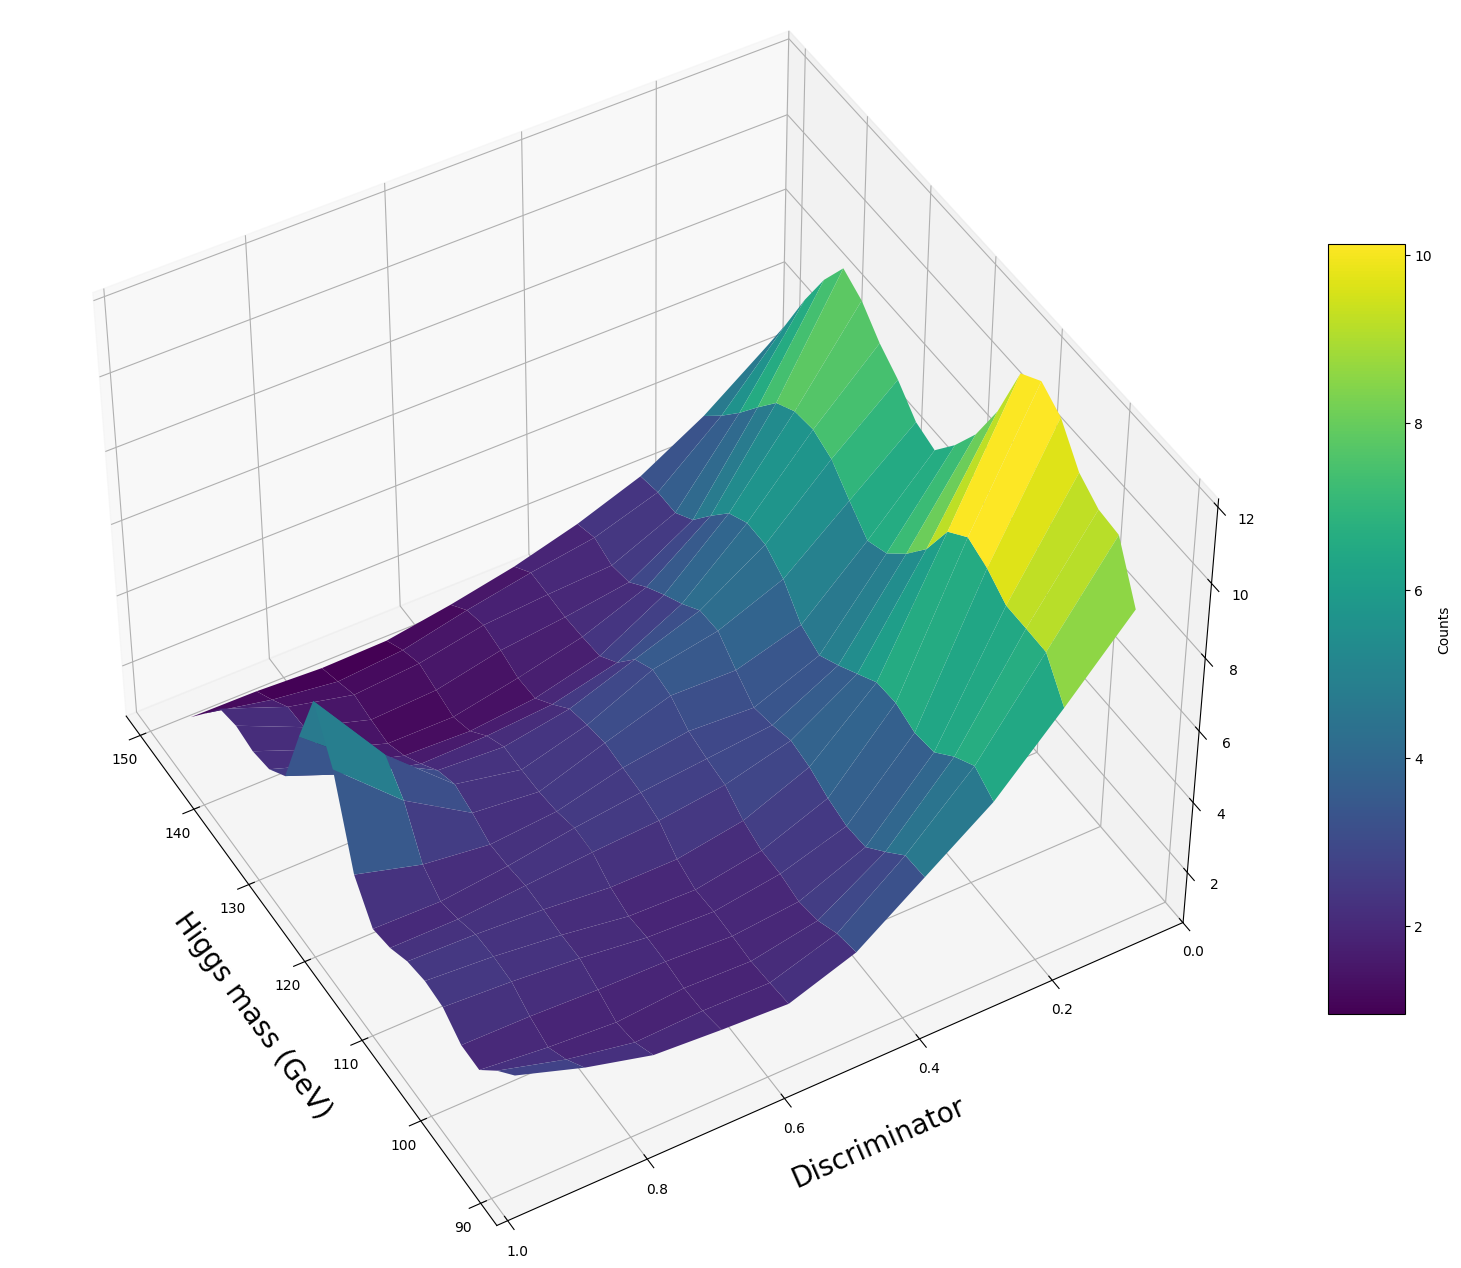

In [23]:
from splitfitter import plot3D

plot3D(sig,bkg,model_basic)